# Jour 3 — CNN : radiographie thoracique (normal vs pneumonie)

Classification binaire d'images en trois itérations sur le même problème :

1. TP1 — CNN from scratch (overfitting attendu)
2. TP2 — CNN + data augmentation + Dropout
3. TP3 — Transfer learning MobileNetV2

Modèle éducatif : il ne constitue en aucun cas un outil de diagnostic médical.

Dataset : radiographies labellisées NORMAL / PNEUMONIA (Kaggle, ~5 856 images). Les classes sont déséquilibrées (~2,7:1 en faveur de pneumonie) ; on le traite avec `class_weight` à l'entraînement, pas en jetant des données.

## Phase 1.1 — Setup et organisation du dataset

Télécharger le dataset via l'API Kaggle, nettoyer l'archive, puis organiser les images en `train` / `val` / `test` par classe.

- **test** : le split officiel du dataset (patient-disjoint), conservé tel quel pour une évaluation finale honnête.
- **train / val** : le `val` officiel ne fait que 16 images, donc on regroupe train + val officiels et on refait un split 80/20 (`seed=42`).

Environnement : conteneur Docker (TensorFlow CPU). Identifiants Kaggle via `KAGGLE_USERNAME` / `KAGGLE_KEY` (`.env`). Données dans des volumes Docker (`/tf/raw`, `/tf/data`).

In [1]:
# Seul endroit à modifier pour changer de dataset.
CLASS_A = 'normal'
CLASS_B = 'pneumonia'

# Dossiers sources correspondants dans l'archive Kaggle.
CLASS_SRC = {CLASS_A: 'NORMAL', CLASS_B: 'PNEUMONIA'}

# Volumes Docker (rapides, hors bind mount Windows).
RAW_ROOT  = '/tf/raw'
DATA_ROOT = '/tf/data'

KAGGLE_DATASET = 'paultimothymooney/chest-xray-pneumonia'

In [2]:
import os, subprocess, shutil

# Identifiants lus depuis KAGGLE_USERNAME / KAGGLE_KEY (voir .env). ~2,3 Go au premier run.
os.makedirs(RAW_ROOT, exist_ok=True)
if not any(os.scandir(RAW_ROOT)):
    subprocess.run(
        ['kaggle', 'datasets', 'download', '-d', KAGGLE_DATASET,
         '-p', RAW_ROOT, '--unzip', '-q'],
        check=True,
    )
    print('Téléchargement terminé.')
else:
    print('Dataset déjà présent, téléchargement ignoré.')

# Nettoyage de l'archive : ce dataset embarque une copie imbriquée chest_xray/chest_xray
# et des dossiers __MACOSX (métadonnées macOS). On les retire pour garder une structure
# propre : chest_xray/{train,val,test}/{NORMAL,PNEUMONIA}.
nested = os.path.join(RAW_ROOT, 'chest_xray', 'chest_xray')
if os.path.isdir(nested):
    shutil.rmtree(nested)
    print('Retiré : chest_xray/chest_xray')
for dirpath, dirs, files in os.walk(RAW_ROOT):
    if '__MACOSX' in dirs:
        shutil.rmtree(os.path.join(dirpath, '__MACOSX'))
        dirs.remove('__MACOSX')
        print('Retiré :', os.path.join(os.path.relpath(dirpath, RAW_ROOT), '__MACOSX'))

Dataset déjà présent, téléchargement ignoré.


In [3]:
# Structure du dataset après nettoyage.
for dirpath, dirs, files in os.walk(os.path.join(RAW_ROOT, 'chest_xray')):
    imgs = [f for f in files if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    niveau = dirpath.replace(RAW_ROOT, '').count(os.sep)
    print('  ' * niveau, os.path.basename(dirpath), '->', len(imgs), 'images')

   chest_xray -> 0 images
     val -> 0 images
       NORMAL -> 8 images
       PNEUMONIA -> 8 images
     test -> 0 images
       NORMAL -> 234 images
       PNEUMONIA -> 390 images
     train -> 0 images
       NORMAL -> 1341 images
       PNEUMONIA -> 3875 images


In [4]:
import random

BASE = os.path.join(RAW_ROOT, 'chest_xray')
IMG_EXT = ('.jpg', '.jpeg', '.png')

def images_in(*parts):
    d = os.path.join(BASE, *parts)
    if not os.path.isdir(d):
        return []
    return [os.path.join(d, f) for f in os.listdir(d)
            if f.lower().endswith(IMG_EXT) and not f.startswith('._')]

def copy_to(paths, split, cls):
    dst = os.path.join(DATA_ROOT, split, cls)
    os.makedirs(dst, exist_ok=True)
    for i, src in enumerate(paths):
        ext = os.path.splitext(src)[1].lower()
        shutil.copy(src, os.path.join(dst, f'{cls}_{i:05d}{ext}'))

# Repartir de dossiers propres. DATA_ROOT est un point de montage : on vide son
# contenu au lieu de le supprimer lui-même.
if os.path.isdir(DATA_ROOT):
    for e in os.scandir(DATA_ROOT):
        shutil.rmtree(e.path) if e.is_dir() else os.remove(e.path)

random.seed(42)
for cls, src in CLASS_SRC.items():
    # test : split officiel conservé tel quel (patient-disjoint).
    copy_to(images_in('test', src), 'test', cls)
    # train/val : regroupe train + val officiels puis re-split 80/20.
    pool = images_in('train', src) + images_in('val', src)
    random.shuffle(pool)
    n_val = int(len(pool) * 0.2)
    copy_to(pool[:n_val], 'val', cls)
    copy_to(pool[n_val:], 'train', cls)

In [5]:
# Comptes par split et par classe : le déséquilibre ~2,7:1 doit rester visible.
for split in ['train', 'val', 'test']:
    for cls in [CLASS_A, CLASS_B]:
        path = os.path.join(DATA_ROOT, split, cls)
        print(f'{path} : {len(os.listdir(path))} images')

/tf/data/train/normal : 1080 images
/tf/data/train/pneumonia : 3107 images
/tf/data/val/normal : 269 images
/tf/data/val/pneumonia : 776 images
/tf/data/test/normal : 234 images
/tf/data/test/pneumonia : 390 images


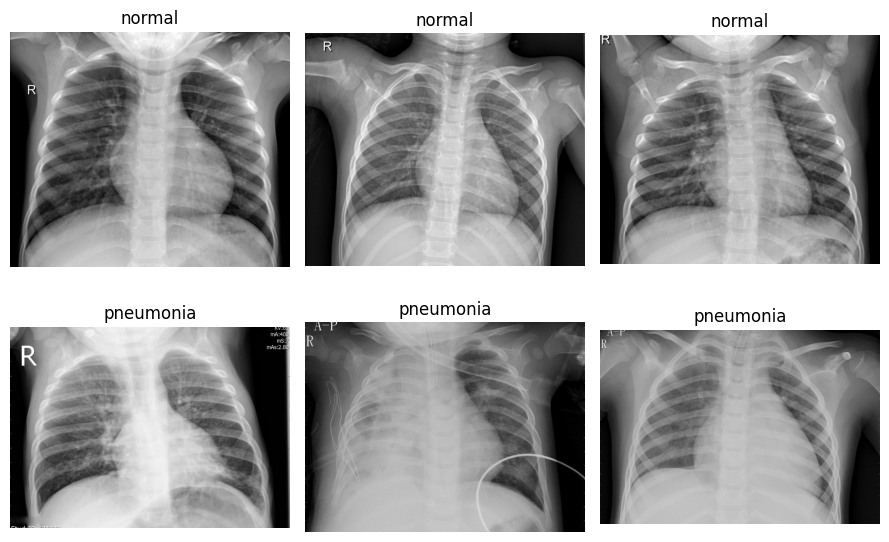

In [6]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

plt.figure(figsize=(9, 6))
for i, cls in enumerate([CLASS_A, CLASS_B]):
    folder = os.path.join(DATA_ROOT, 'train', cls)
    for j, fname in enumerate(os.listdir(folder)[:3]):
        img = mpimg.imread(os.path.join(folder, fname))
        plt.subplot(2, 3, i * 3 + j + 1)
        plt.imshow(img, cmap='gray')
        plt.title(cls)
        plt.axis('off')
plt.tight_layout()
plt.show()